# Project 2 — Gaussian Mixture Models and Soft Clustering

K-Means gives each sample exactly one cluster label. Gaussian Mixture Models (GMMs) go further: they estimate the probability that a sample belongs to each latent component. This is useful when clusters overlap, when points lie near boundaries, or when cluster shapes are elliptical rather than spherical.

In this notebook, the Wine dataset has known classes, but the clustering models do not use those labels during fitting. The labels are used only as an external reference to check how discovered clusters align with known groups.

## Prerequisites

The notebook assumes basic clustering intuition, basic probability distributions, and an intuitive understanding of mean and covariance. PCA is used for visualization, but the clustering is performed on the scaled feature space unless otherwise stated.

## Problem statement

Given multivariate chemical measurements of wine samples, identify latent groups and quantify uncertainty in group membership using Gaussian Mixture Models.

The central question is not only “which group does a sample belong to?” but also “how confident is the model in that assignment?”

In [1]:
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

In [2]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="true_class")

print(X.shape)
display(X.head())
display(y.value_counts().sort_index().rename("class_count"))

(178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


0    59
1    71
2    48
Name: class_count, dtype: int64

## Dataset description and initial EDA

The Wine dataset contains continuous chemical measurements from wine samples belonging to three known cultivars. In this notebook, those class labels are treated only as an external validation aid. The models themselves see only the feature matrix.

A first inspection of feature distributions and correlations helps us understand whether groups might differ by combinations of variables rather than by one feature alone.

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83
malic_acid,178.0,2.336,1.117,0.74,1.602,1.865,3.082,5.80
ash,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23
alcalinity_of_ash,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00
magnesium,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00
total_phenols,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88
flavanoids,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08
nonflavanoid_phenols,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66
proanthocyanins,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58
color_intensity,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00


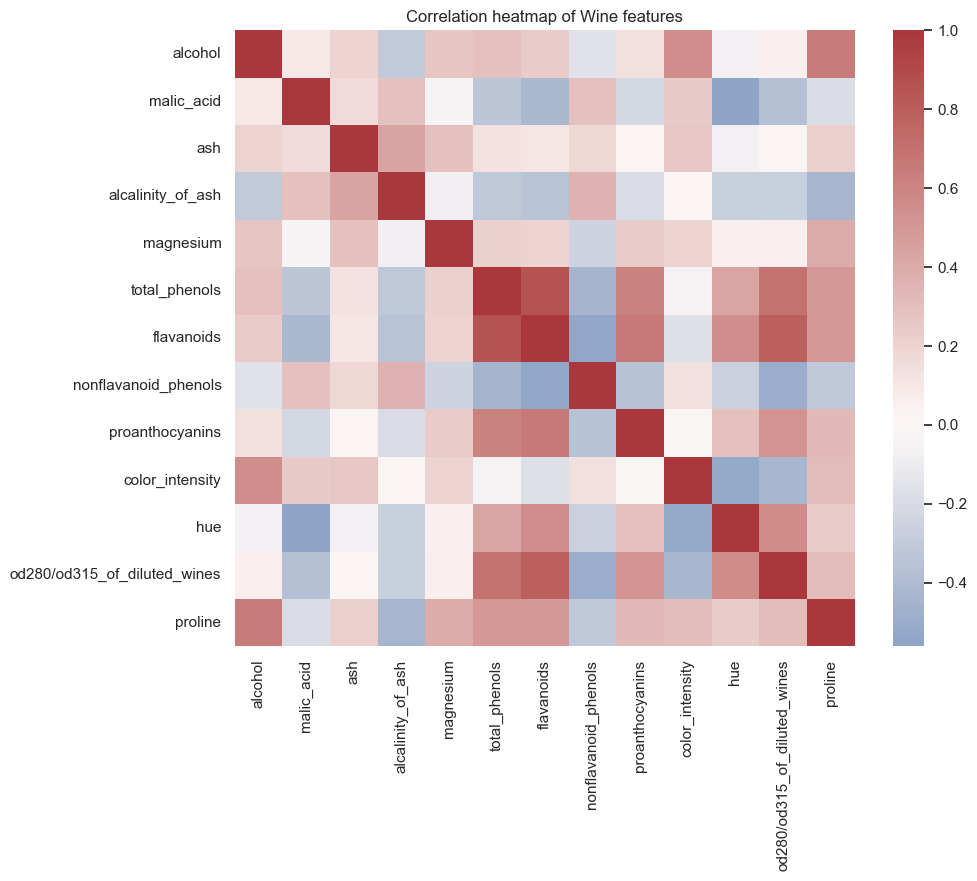

In [3]:
display(X.describe().T.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap="vlag", center=0)
plt.title("Correlation heatmap of Wine features")
plt.show()

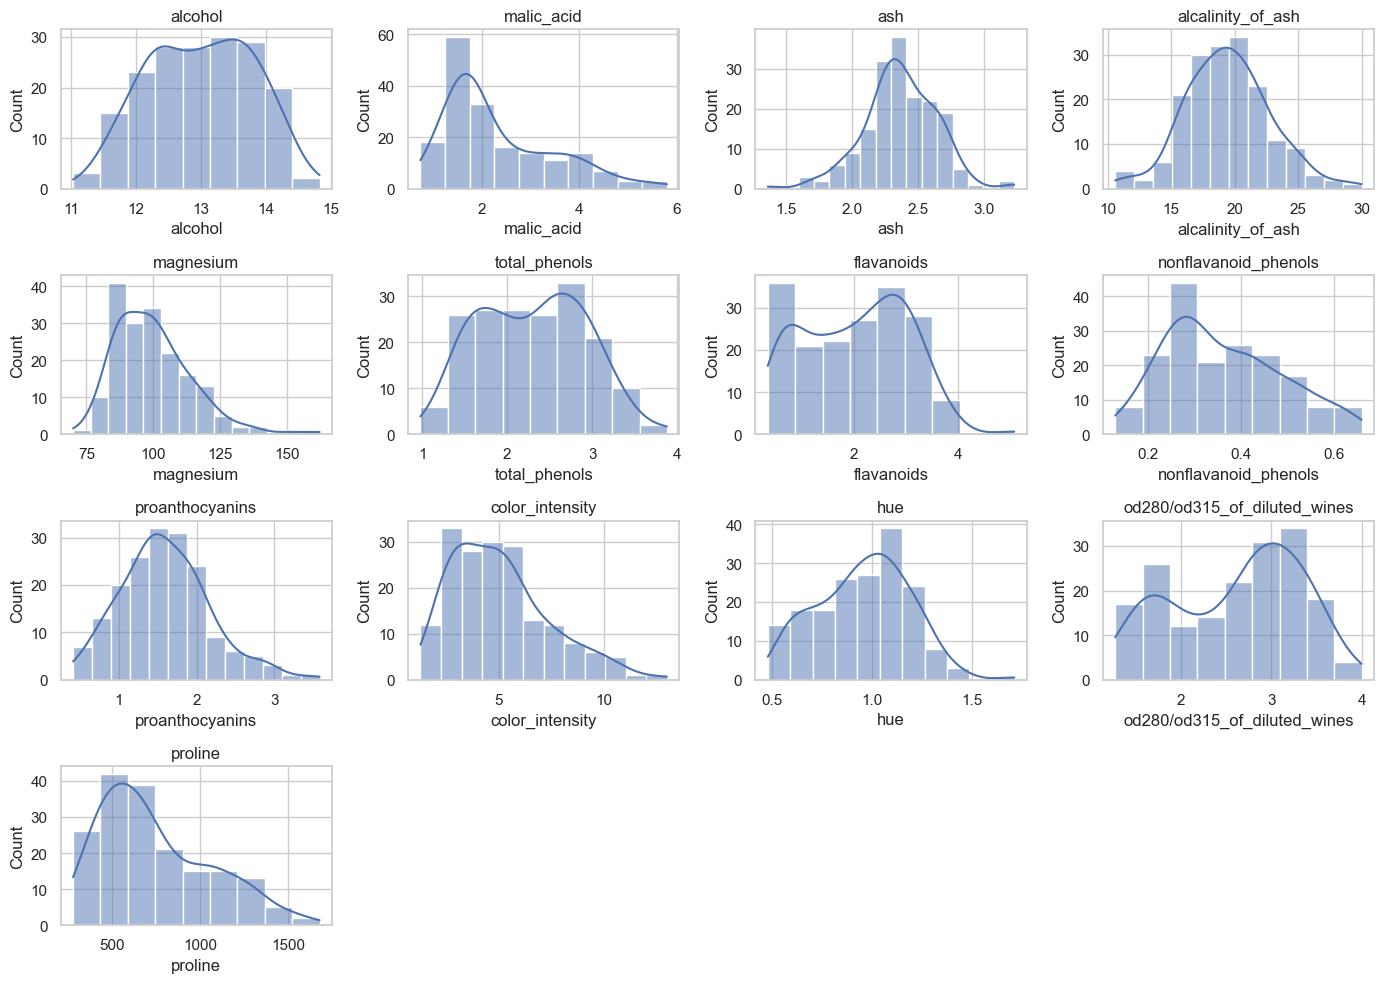

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(X.columns):
    sns.histplot(X[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(X.columns), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Scaling and PCA reference view

Both K-Means and GMM are affected by feature scale. K-Means uses distance directly, while GMM uses likelihood under Gaussian components; in both cases, a feature with a large numerical range can dominate the learned structure.

The PCA plots below are reference views. PCA uses no labels, but coloring by true class helps us see how much the known classes appear separated in a two-dimensional projection.

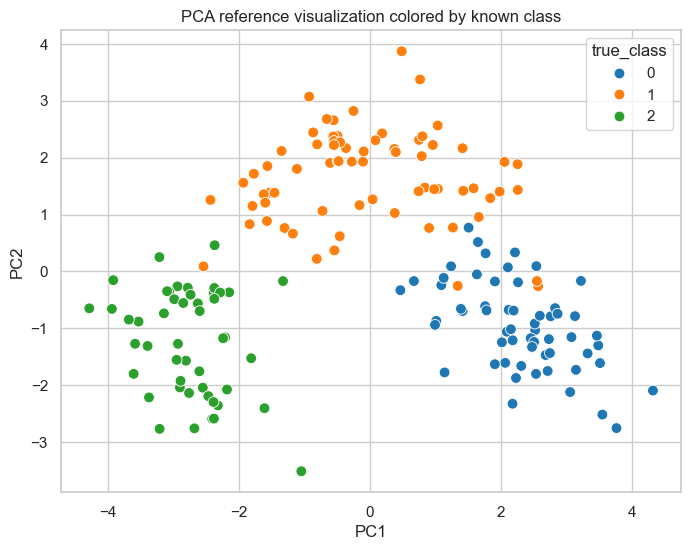

Explained variance ratio: [0.36198848 0.1920749 ]


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["true_class"] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="true_class", palette="tab10", s=60)
plt.title("PCA reference visualization colored by known class")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## K-Means as a hard-clustering baseline

K-Means represents each cluster by a centroid and assigns every point to exactly one cluster. This hard assignment is simple and often effective, but it cannot represent uncertainty. If a sample lies between two clusters, K-Means still forces it into one.

In [6]:
kmeans = KMeans(n_clusters=3, n_init=30, random_state=RANDOM_STATE)
km_labels = kmeans.fit_predict(X_scaled)

km_metrics = {
    "silhouette": silhouette_score(X_scaled, km_labels),
    "ARI_external": adjusted_rand_score(y, km_labels),
    "NMI_external": normalized_mutual_info_score(y, km_labels)
}
display(pd.Series(km_metrics))

pd.crosstab(pd.Series(km_labels, name="kmeans_cluster"), y, colnames=["true_class"])

silhouette      0.284859
ARI_external    0.897495
NMI_external    0.875894
dtype: float64

true_class,0,1,2
kmeans_cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


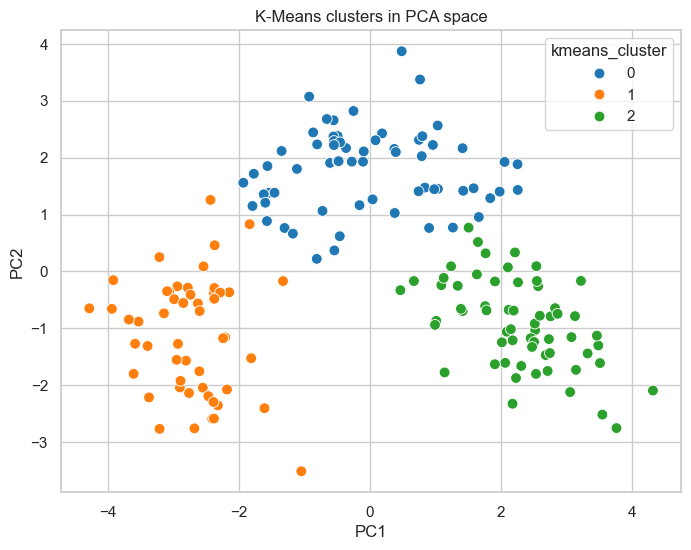

In [7]:
plot_df = pca_df.copy()
plot_df["kmeans_cluster"] = km_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="kmeans_cluster", palette="tab10", s=60)
plt.title("K-Means clusters in PCA space")
plt.show()

## GMM theory: mixture modeling and soft assignment

A Gaussian Mixture Model assumes that the data distribution is a weighted mixture of several Gaussian components:

\[
p(x)=\sum_{k=1}^{K}\pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)
\]

Each component has a mean vector, a covariance matrix, and a mixing weight. The model estimates both component shapes and the probability that each sample belongs to each component.

GMM is usually fitted by Expectation-Maximization:

- **E-step**: estimate membership probabilities using current component parameters.
- **M-step**: update component means, covariances, and weights using those probabilities.

This alternates until the likelihood improves very little.

## Basic GMM with three components

We start with three components because the Wine dataset has three known classes. This does not mean the model is told the labels; it simply receives a choice of component count.

In [8]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    n_init=10,
    reg_covar=1e-6,
    random_state=RANDOM_STATE
)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

gmm_metrics = {
    "silhouette": silhouette_score(X_scaled, gmm_labels),
    "ARI_external": adjusted_rand_score(y, gmm_labels),
    "NMI_external": normalized_mutual_info_score(y, gmm_labels),
    "AIC": gmm.aic(X_scaled),
    "BIC": gmm.bic(X_scaled)
}
display(pd.Series(gmm_metrics))
display(pd.crosstab(pd.Series(gmm_labels, name="gmm_component"), y, colnames=["true_class"]))

prob_preview = pd.DataFrame(gmm_probs, columns=[f"prob_component_{i}" for i in range(gmm_probs.shape[1])])
prob_preview["assigned_component"] = gmm_labels
prob_preview["max_probability"] = prob_preview.filter(like="prob_component").max(axis=1)
prob_preview.head(10).round(3)

silhouette         0.284421
ARI_external       0.880400
NMI_external       0.860946
AIC             4807.205086
BIC             5806.285121
dtype: float64

true_class,0,1,2
gmm_component,,,
0,59,4,0
1,0,64,0
2,0,3,48


,prob_component_0,prob_component_1,prob_component_2,assigned_component,max_probability
0,1.0,0.0,0.0,0,1.0
1,1.0,0.0,0.0,0,1.0
2,1.0,0.0,0.0,0,1.0
3,1.0,0.0,0.0,0,1.0
4,1.0,0.0,0.0,0,1.0
5,1.0,0.0,0.0,0,1.0
6,1.0,0.0,0.0,0,1.0
7,1.0,0.0,0.0,0,1.0
8,1.0,0.0,0.0,0,1.0
9,1.0,0.0,0.0,0,1.0


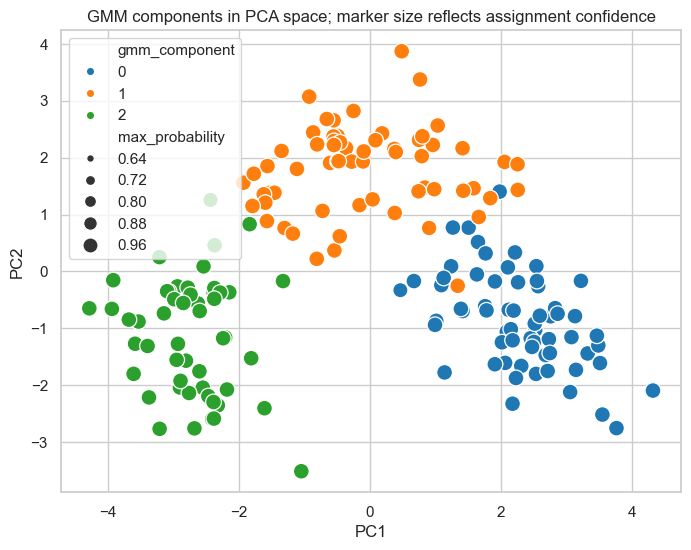

In [9]:
plot_df = pca_df.copy()
plot_df["gmm_component"] = gmm_labels
plot_df["max_probability"] = gmm_probs.max(axis=1)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df, x="PC1", y="PC2",
    hue="gmm_component", size="max_probability",
    sizes=(30, 130), palette="tab10"
)
plt.title("GMM components in PCA space; marker size reflects assignment confidence")
plt.show()

A point with one probability close to 1 is assigned confidently. A point with probabilities spread across components lies near a boundary or in a region where component densities overlap. This uncertainty is a major practical advantage of GMM over hard clustering.

## Number of components: AIC, BIC, and clustering metrics

The number of components controls the flexibility of the density model. More components can fit more complex distributions, but they can also overfit.

AIC and BIC balance likelihood against model complexity. BIC penalizes complexity more strongly than AIC. Importantly, the best number of density components may differ from the number of semantic classes.

In [10]:
component_rows = []

for n in range(1, 11):
    model = GaussianMixture(n_components=n, covariance_type="full", n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    row = {
        "n_components": n,
        "AIC": model.aic(X_scaled),
        "BIC": model.bic(X_scaled)
    }
    if n > 1:
        row["silhouette"] = silhouette_score(X_scaled, labels)
        row["ARI_external"] = adjusted_rand_score(y, labels)
        row["NMI_external"] = normalized_mutual_info_score(y, labels)
    else:
        row["silhouette"] = np.nan
        row["ARI_external"] = np.nan
        row["NMI_external"] = np.nan
    component_rows.append(row)

component_df = pd.DataFrame(component_rows)
component_df

,n_components,AIC,BIC,silhouette,ARI_external,NMI_external
0,1,5410.396412,5741.301901,NaN,NaN,NaN
1,2,4943.357075,5608.349837,0.268505,0.461004,0.598639
2,3,4807.205086,5806.285121,0.284421,0.880400,0.860946
3,4,4473.652966,5806.820274,0.254228,0.817179,0.798351
4,5,4253.183461,5920.438042,0.239124,0.776067,0.810086
5,6,4224.813567,6226.155420,0.240109,0.674997,0.728120
6,7,4305.367998,6640.797124,0.152817,0.504083,0.644600
7,8,3738.403064,6407.919463,0.162504,0.494694,0.617612
8,9,3445.051893,6448.655564,0.167417,0.489697,0.617093
9,10,3148.978005,6486.668949,0.136678,0.397768,0.576285


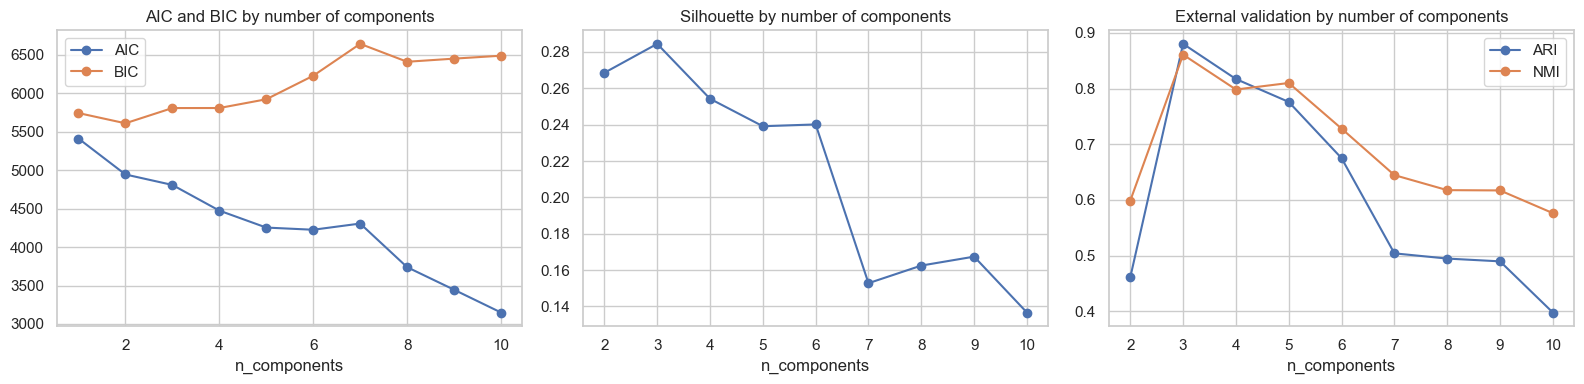

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(component_df["n_components"], component_df["AIC"], marker="o", label="AIC")
axes[0].plot(component_df["n_components"], component_df["BIC"], marker="o", label="BIC")
axes[0].set_title("AIC and BIC by number of components")
axes[0].set_xlabel("n_components")
axes[0].legend()

axes[1].plot(component_df["n_components"], component_df["silhouette"], marker="o")
axes[1].set_title("Silhouette by number of components")
axes[1].set_xlabel("n_components")

axes[2].plot(component_df["n_components"], component_df["ARI_external"], marker="o", label="ARI")
axes[2].plot(component_df["n_components"], component_df["NMI_external"], marker="o", label="NMI")
axes[2].set_title("External validation by number of components")
axes[2].set_xlabel("n_components")
axes[2].legend()

plt.tight_layout()
plt.show()

### Reading model-selection criteria together

AIC, BIC, silhouette, and external agreement metrics answer different questions. AIC/BIC ask whether the density model is worth its complexity. Silhouette asks whether the resulting hard labels are geometrically separated. ARI/NMI compare discovered components with known wine classes, but those labels were not used during fitting. Looking at these together helps avoid the mistake of treating one metric as the only truth.

In [13]:
metric_summary = component_df.copy()

# The external-validation columns are intentionally named with the suffix "_external"
# to remind us that Wine labels are used only after clustering, not during fitting.
rank_cols = ["AIC", "BIC", "silhouette", "ARI_external", "NMI_external"]

for col in rank_cols:
    if col in metric_summary.columns:
        ascending = col in ["AIC", "BIC"]
        metric_summary[col + "_rank"] = metric_summary[col].rank(
            ascending=ascending, method="min"
        )

display(metric_summary.round(3))

best_by = {
    "AIC_min": int(component_df.loc[component_df["AIC"].idxmin(), "n_components"]),
    "BIC_min": int(component_df.loc[component_df["BIC"].idxmin(), "n_components"]),
    "silhouette_max": int(component_df.loc[component_df["silhouette"].idxmax(), "n_components"]),
    "ARI_max_external_reference": int(component_df.loc[component_df["ARI_external"].idxmax(), "n_components"]),
    "NMI_max_external_reference": int(component_df.loc[component_df["NMI_external"].idxmax(), "n_components"]),
}

display(pd.Series(best_by, name="suggested_n_components"))

,n_components,AIC,BIC,silhouette,ARI_external,NMI_external,AIC_rank,BIC_rank,silhouette_rank,ARI_external_rank,NMI_external_rank
0,1,5410.396,5741.302,NaN,NaN,NaN,10.0,2.0,NaN,NaN,NaN
1,2,4943.357,5608.350,0.269,0.461,0.599,9.0,1.0,2.0,8.0,8.0
2,3,4807.205,5806.285,0.284,0.880,0.861,8.0,3.0,1.0,1.0,1.0
3,4,4473.653,5806.820,0.254,0.817,0.798,7.0,4.0,3.0,2.0,3.0
4,5,4253.183,5920.438,0.239,0.776,0.810,5.0,5.0,5.0,3.0,2.0
5,6,4224.814,6226.155,0.240,0.675,0.728,4.0,6.0,4.0,4.0,4.0
6,7,4305.368,6640.797,0.153,0.504,0.645,6.0,10.0,8.0,5.0,5.0
7,8,3738.403,6407.919,0.163,0.495,0.618,3.0,7.0,7.0,6.0,6.0
8,9,3445.052,6448.656,0.167,0.490,0.617,2.0,8.0,6.0,7.0,7.0
9,10,3148.978,6486.669,0.137,0.398,0.576,1.0,9.0,9.0,9.0,9.0


AIC_min                       10
BIC_min                        2
silhouette_max                 3
ARI_max_external_reference     3
NMI_max_external_reference     3
Name: suggested_n_components, dtype: int64

Different suggestions are normal: density modeling, geometric separation, and class agreement are not identical objectives.

## Covariance type

The covariance structure controls the shape each Gaussian component can take:

- `spherical`: each component has one variance value.
- `diag`: each feature has its own variance, but features are assumed uncorrelated within each component.
- `tied`: all components share one covariance matrix.
- `full`: each component has its own full covariance matrix.

Full covariance is the most flexible and can model tilted elliptical clusters, but it uses more parameters and can overfit small datasets.

In [14]:
cov_rows = []

for cov_type in ["spherical", "diag", "tied", "full"]:
    model = GaussianMixture(
        n_components=3,
        covariance_type=cov_type,
        n_init=10,
        random_state=RANDOM_STATE,
        reg_covar=1e-6
    )
    labels = model.fit_predict(X_scaled)
    cov_rows.append({
        "covariance_type": cov_type,
        "AIC": model.aic(X_scaled),
        "BIC": model.bic(X_scaled),
        "silhouette": silhouette_score(X_scaled, labels),
        "ARI_external": adjusted_rand_score(y, labels),
        "NMI_external": normalized_mutual_info_score(y, labels)
    })

cov_df = pd.DataFrame(cov_rows).sort_values("BIC")
cov_df

,covariance_type,AIC,BIC,silhouette,ARI_external,NMI_external
1,diag,5288.823637,5543.366321,0.279860,0.915021,0.892451
2,tied,5150.942382,5570.937811,0.281441,0.945885,0.936856
0,spherical,5568.768373,5708.766849,0.271915,0.878619,0.855200
3,full,4807.205086,5806.285121,0.284421,0.880400,0.860946


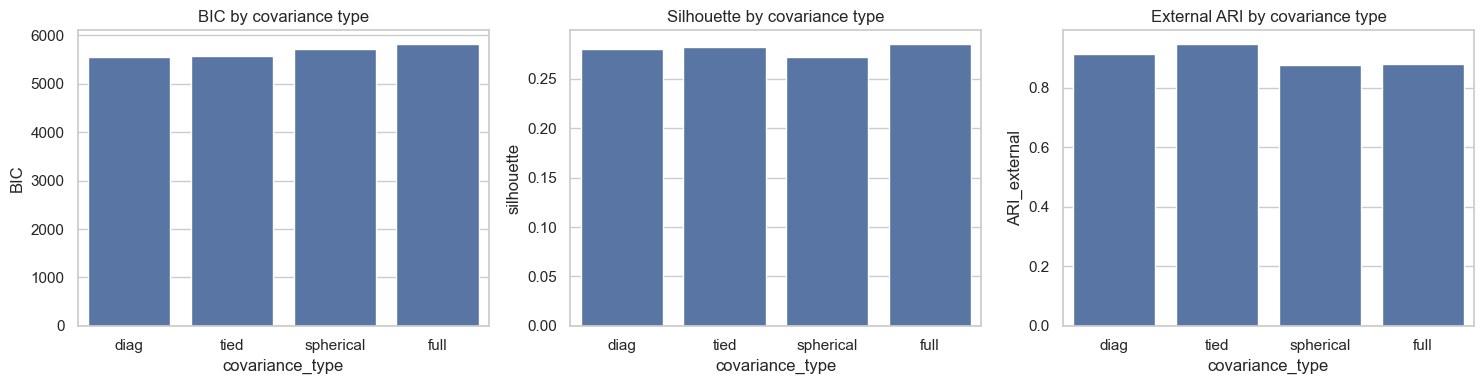

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=cov_df, x="covariance_type", y="BIC", ax=axes[0])
axes[0].set_title("BIC by covariance type")

sns.barplot(data=cov_df, x="covariance_type", y="silhouette", ax=axes[1])
axes[1].set_title("Silhouette by covariance type")

sns.barplot(data=cov_df, x="covariance_type", y="ARI_external", ax=axes[2])
axes[2].set_title("External ARI by covariance type")

plt.tight_layout()
plt.show()

## Regularization and numerical stability

`reg_covar` adds a small value to covariance diagonals. This prevents numerical problems when a component covariance becomes too small or nearly singular. Too little regularization may be unstable; too much may oversmooth component shapes.

In [16]:
reg_rows = []

for reg in [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]:
    model = GaussianMixture(
        n_components=3,
        covariance_type="full",
        n_init=10,
        reg_covar=reg,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_scaled)
    reg_rows.append({
        "reg_covar": reg,
        "AIC": model.aic(X_scaled),
        "BIC": model.bic(X_scaled),
        "silhouette": silhouette_score(X_scaled, labels),
        "ARI_external": adjusted_rand_score(y, labels),
        "avg_max_probability": model.predict_proba(X_scaled).max(axis=1).mean()
    })

reg_df = pd.DataFrame(reg_rows)
reg_df

,reg_covar,AIC,BIC,silhouette,ARI_external,avg_max_probability
0,0.000001,4807.205086,5806.285121,0.284421,0.880400,0.997288
1,0.000010,4807.205132,5806.285167,0.284421,0.880400,0.997288
2,0.000100,4807.207120,5806.287155,0.284421,0.880400,0.997290
3,0.001000,4795.171131,5794.251165,0.271621,0.877664,0.993953
4,0.010000,4809.039399,5808.119434,0.279837,0.911196,0.996650


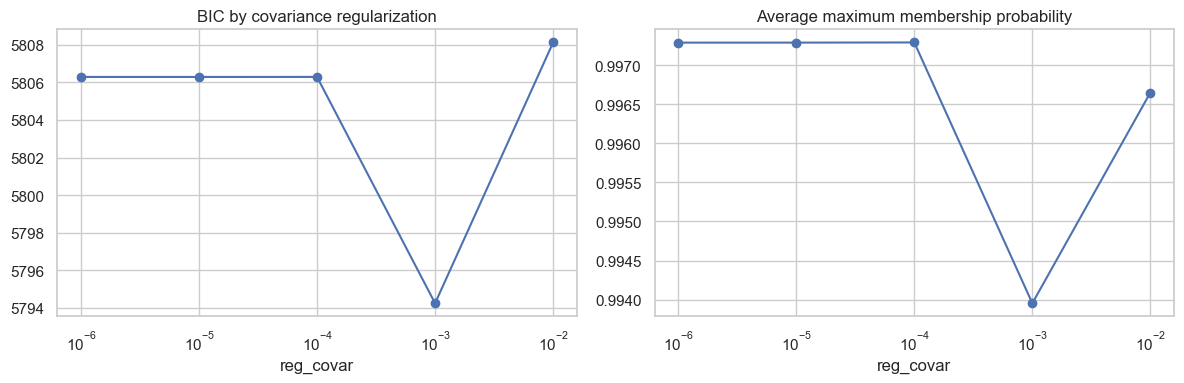

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(reg_df["reg_covar"], reg_df["BIC"], marker="o")
axes[0].set_title("BIC by covariance regularization")
axes[0].set_xlabel("reg_covar")

axes[1].semilogx(reg_df["reg_covar"], reg_df["avg_max_probability"], marker="o")
axes[1].set_title("Average maximum membership probability")
axes[1].set_xlabel("reg_covar")

plt.tight_layout()
plt.show()

## Initialization and random-state sensitivity

GMM optimization is non-convex, so it can converge to local optima. Initialization matters. A stable setting should not change drastically across random seeds.

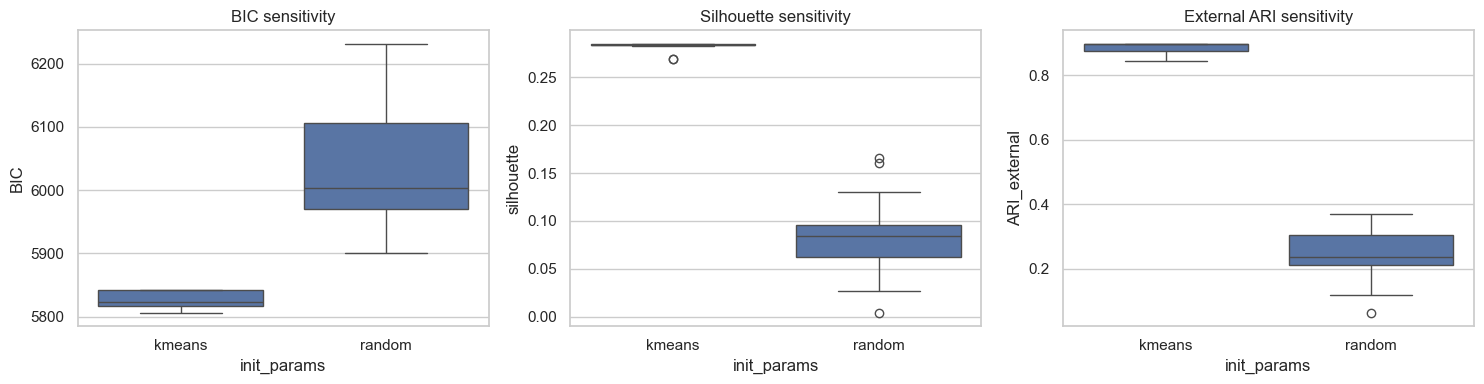

In [18]:
init_rows = []

for init in ["kmeans", "random"]:
    for seed in range(20):
        model = GaussianMixture(
            n_components=3,
            covariance_type="full",
            init_params=init,
            n_init=1,
            random_state=seed
        )
        labels = model.fit_predict(X_scaled)
        init_rows.append({
            "init_params": init,
            "seed": seed,
            "BIC": model.bic(X_scaled),
            "silhouette": silhouette_score(X_scaled, labels),
            "ARI_external": adjusted_rand_score(y, labels)
        })

init_df = pd.DataFrame(init_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=init_df, x="init_params", y="BIC", ax=axes[0])
axes[0].set_title("BIC sensitivity")
sns.boxplot(data=init_df, x="init_params", y="silhouette", ax=axes[1])
axes[1].set_title("Silhouette sensitivity")
sns.boxplot(data=init_df, x="init_params", y="ARI_external", ax=axes[2])
axes[2].set_title("External ARI sensitivity")
plt.tight_layout()
plt.show()

## Soft assignment and uncertainty analysis

Soft probabilities let us identify samples that do not clearly belong to one component. In many scientific or business applications, these uncertain cases are the most informative because they may represent transitions, mixed groups, or ambiguous measurements.

count    178.000000
mean       0.997288
std        0.027320
min        0.639450
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: max_probability, dtype: float64

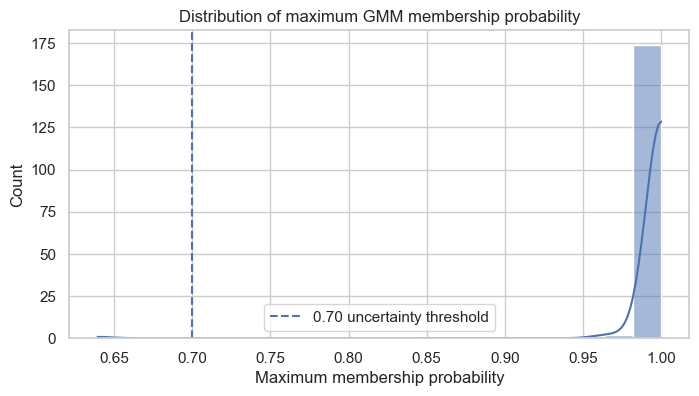

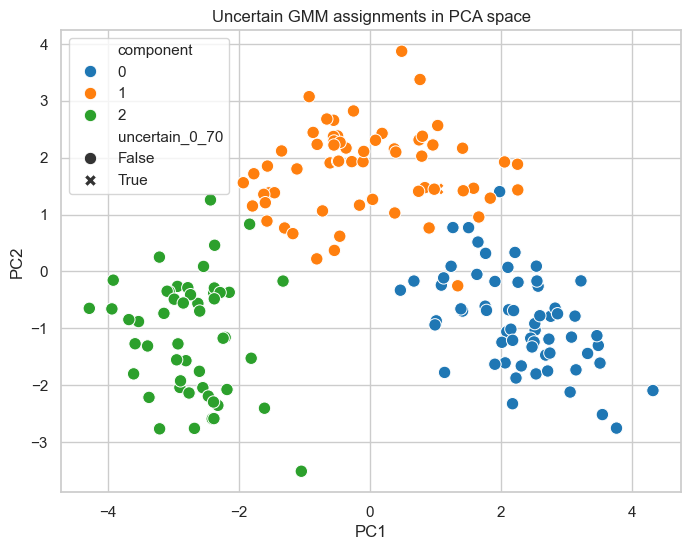

In [19]:
uncertainty_df = pca_df.copy()
uncertainty_df["component"] = gmm_labels
uncertainty_df["max_probability"] = gmm_probs.max(axis=1)
uncertainty_df["uncertain_0_70"] = uncertainty_df["max_probability"] < 0.70

display(uncertainty_df["max_probability"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(uncertainty_df["max_probability"], bins=20, kde=True)
plt.axvline(0.70, linestyle="--", label="0.70 uncertainty threshold")
plt.title("Distribution of maximum GMM membership probability")
plt.xlabel("Maximum membership probability")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=uncertainty_df, x="PC1", y="PC2",
    hue="component", style="uncertain_0_70",
    palette="tab10", s=80
)
plt.title("Uncertain GMM assignments in PCA space")
plt.show()

### Entropy-based uncertainty and external-label error analysis

The maximum membership probability is intuitive, but entropy uses the full probability vector. Low entropy means one component dominates; high entropy means the model spreads belief across components. Because the Wine dataset has known labels, we can also check whether uncertain points are more likely to disagree with the majority class of their assigned component. This is not supervised training; it is a post-hoc diagnostic.

,count,mean
confidence_band,,
<=0.60,0,NaN
0.60-0.80,1,1.00
0.80-0.95,0,NaN
>0.95,177,0.96


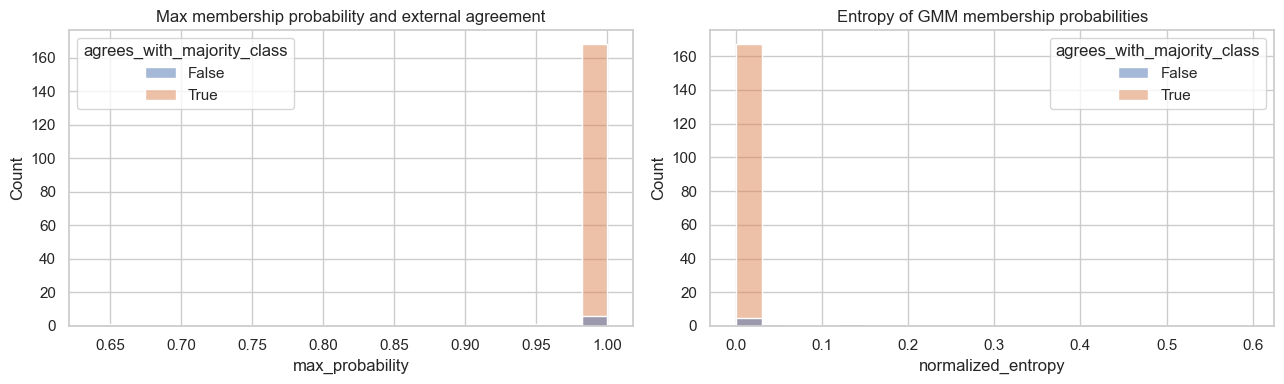

In [20]:
eps = 1e-12
entropy = -(gmm_probs * np.log(gmm_probs + eps)).sum(axis=1) / np.log(gmm_probs.shape[1])
uncertainty_df["normalized_entropy"] = entropy
uncertainty_df["true_class"] = y

# Map each GMM component to the majority true class only for external diagnostic interpretation.
component_to_majority_class = (
    uncertainty_df.groupby("component")["true_class"]
    .agg(lambda s: s.value_counts().idxmax())
    .to_dict()
)
uncertainty_df["component_majority_class"] = uncertainty_df["component"].map(component_to_majority_class)
uncertainty_df["agrees_with_majority_class"] = uncertainty_df["true_class"] == uncertainty_df["component_majority_class"]
uncertainty_df["confidence_band"] = pd.cut(
    uncertainty_df["max_probability"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["<=0.60", "0.60-0.80", "0.80-0.95", ">0.95"],
    include_lowest=True
)

display(uncertainty_df.groupby("confidence_band", observed=False)["agrees_with_majority_class"].agg(["count", "mean"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=uncertainty_df, x="max_probability", hue="agrees_with_majority_class", bins=20, ax=axes[0])
axes[0].set_title("Max membership probability and external agreement")
sns.histplot(data=uncertainty_df, x="normalized_entropy", hue="agrees_with_majority_class", bins=20, ax=axes[1])
axes[1].set_title("Entropy of GMM membership probabilities")
plt.tight_layout()
plt.show()

## Comparing K-Means and GMM

The comparison below emphasizes modeling assumptions, not just metrics. K-Means is simple and fast; GMM is probabilistic and can represent elliptical clusters, but it is more sensitive to covariance assumptions and initialization.

### How many parameters does flexibility add?

The covariance type changes not only cluster shape but also model complexity. This compact table shows how the number of free parameters grows as the number of components increases. It helps explain why full covariance can fit richer shapes but can also overfit small datasets.

covariance_type,diag,full,spherical,tied
n_components,,,,
1,26,104,14,104
2,53,209,29,118
3,80,314,44,132
4,107,419,59,146
5,134,524,74,160
6,161,629,89,174
7,188,734,104,188


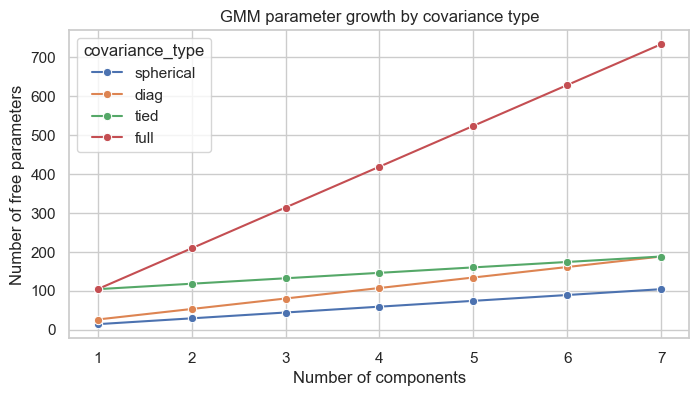

In [21]:
complexity_rows = []
for n in range(1, 8):
    for cov_type in ["spherical", "diag", "tied", "full"]:
        m = GaussianMixture(n_components=n, covariance_type=cov_type, random_state=RANDOM_STATE)
        m.fit(X_scaled)
        complexity_rows.append({
            "n_components": n,
            "covariance_type": cov_type,
            "n_parameters": m._n_parameters(),
            "BIC": m.bic(X_scaled)
        })

complexity_df = pd.DataFrame(complexity_rows)
display(complexity_df.pivot(index="n_components", columns="covariance_type", values="n_parameters"))

plt.figure(figsize=(8, 4))
sns.lineplot(data=complexity_df, x="n_components", y="n_parameters", hue="covariance_type", marker="o")
plt.title("GMM parameter growth by covariance type")
plt.xlabel("Number of components")
plt.ylabel("Number of free parameters")
plt.show()

In [22]:
comparison = pd.DataFrame([
    {
        "Method": "K-Means",
        "Assumption": "Compact spherical clusters around centroids",
        "Assignment": "Hard",
        "Key hyperparameters": "k, n_init, initialization",
        "Silhouette": silhouette_score(X_scaled, km_labels),
        "ARI_external": adjusted_rand_score(y, km_labels),
        "NMI_external": normalized_mutual_info_score(y, km_labels),
        "Interpretability note": "Simple centroid profiles; no uncertainty estimate."
    },
    {
        "Method": "GMM",
        "Assumption": "Mixture of Gaussian components",
        "Assignment": "Soft probabilities plus hard labels",
        "Key hyperparameters": "n_components, covariance_type, reg_covar, initialization",
        "Silhouette": silhouette_score(X_scaled, gmm_labels),
        "ARI_external": adjusted_rand_score(y, gmm_labels),
        "NMI_external": normalized_mutual_info_score(y, gmm_labels),
        "Interpretability note": "Probabilistic components and uncertainty; may overfit if too flexible."
    }
])
comparison

,Method,Assumption,Assignment,Key hyperparameters,Silhouette,ARI_external,NMI_external,Interpretability note
0,K-Means,Compact spherical clusters around centroids,Hard,"k, n_init, initialization",0.284859,0.897495,0.875894,Simple centroid profiles; no uncertainty estim...
1,GMM,Mixture of Gaussian components,Soft probabilities plus hard labels,"n_components, covariance_type, reg_covar, init...",0.284421,0.880400,0.860946,Probabilistic components and uncertainty; may ...


## Limitations

GMM assumes Gaussian components. Components may not correspond to real classes. The model is sensitive to scaling, covariance type, initialization, and regularization. AIC and BIC guide density modeling, not necessarily semantic clustering. PCA visualization may distort separation.

## What we learned

GMM extends clustering into probability. Soft assignments reveal uncertainty. Component count and covariance structure strongly affect results. Model selection criteria help, but final interpretation should consider the objective.

## Possible extensions

Extensions include GMM-based anomaly detection, Bayesian Gaussian Mixture Models, mixture of factor analyzers, customer RFM soft clustering, semi-supervised use of membership probabilities, and density estimation.